# Taller Práctico No. 4 — NumPy, Matplotlib y Seaborn

**Universidad del Pacífico — Programa de Ingeniería de Sistemas**
**Asignatura:** Inteligencia Artificial
**Semestre:** 8 — Corte II
**Caso de estudio seleccionado:** Caso 1 — Predicción de Rotación de Empleados en una Empresa Tecnológica

Este notebook desarrolla de manera completa e integrada las dos partes exigidas por la guía del taller: la Parte I, correspondiente a la investigación conceptual y los ejercicios guía de NumPy, Matplotlib y Seaborn; y la Parte II, correspondiente al caso de estudio integrador sobre rotación de personal, incluyendo generación de datos sintéticos, análisis estadístico, visualización, análisis exploratorio, conclusiones, recomendaciones y reflexión sobre Inteligencia Artificial.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


---

# Parte I — Investigación y Análisis

## Actividad 1. Investigación Conceptual

A continuación se desarrollan las trece preguntas conceptuales solicitadas, organizadas según la librería a la que corresponden.

### NumPy

**1. ¿Qué es NumPy?**

NumPy (Numerical Python) es una librería de código abierto para el lenguaje Python orientada al cálculo numérico y científico. Su componente central es el objeto `ndarray`, una estructura de datos que permite almacenar y manipular colecciones homogéneas de números organizadas en una o varias dimensiones. NumPy provee, además, un extenso conjunto de funciones matemáticas, estadísticas y de álgebra lineal optimizadas para operar sobre estas estructuras de manera eficiente, constituyéndose en la base numérica sobre la que se construye prácticamente todo el ecosistema científico de Python.

**2. ¿Por qué NumPy es más eficiente que las listas tradicionales de Python?**

Las listas de Python son estructuras heterogéneas y dinámicas: cada elemento es en realidad un objeto independiente con su propia información de tipo, lo que añade una sobrecarga considerable de memoria y de tiempo de procesamiento al recorrerlas. Los arreglos de NumPy, en cambio, almacenan los datos en bloques contiguos de memoria, con un único tipo de dato fijo para todos los elementos. Esto permite que las operaciones se ejecuten mediante rutinas compiladas en C y aprovechen mecanismos de vectorización, evitando los bucles explícitos de Python e incrementando notablemente la velocidad de cómputo, especialmente al trabajar con grandes volúmenes de datos.

**3. ¿Qué es un ndarray?**

Un `ndarray` (n-dimensional array) es la estructura de datos fundamental de NumPy: un arreglo multidimensional de elementos del mismo tipo, indexado mediante una tupla de enteros no negativos. Puede representar desde un vector unidimensional hasta tensores de múltiples dimensiones, y posee atributos propios como `shape` (forma), `dtype` (tipo de dato) y `ndim` (número de dimensiones), que permiten describir completamente su estructura interna.

**4. ¿Qué relación existe entre NumPy y el álgebra lineal?**

NumPy implementa de forma nativa las operaciones fundamentales del álgebra lineal: multiplicación de matrices, transposición, cálculo de determinantes, inversas, autovalores y autovectores, descomposiciones matriciales, entre otras, principalmente a través de su submódulo `numpy.linalg`. Dado que los modelos de aprendizaje automático y las redes neuronales expresan sus operaciones internas —combinaciones lineales, productos punto, transformaciones de espacio— en términos de vectores y matrices, NumPy actúa como el motor que materializa computacionalmente estas operaciones algebraicas.

**5. ¿Cómo utilizan los modelos de Deep Learning las matrices de NumPy?**

En Deep Learning, tanto los datos de entrada (imágenes, texto vectorizado, series temporales) como los parámetros del modelo (pesos y sesgos de cada capa) se representan como arreglos multidimensionales. El proceso de propagación hacia adelante consiste en sucesivas multiplicaciones matriciales y aplicaciones de funciones de activación sobre estos arreglos, mientras que el entrenamiento mediante retropropagación calcula gradientes que también se almacenan y actualizan como arreglos NumPy (o estructuras equivalentes en librerías como TensorFlow y PyTorch, que replican su interfaz). Por ello, comprender NumPy es un prerrequisito conceptual para entender cómo operan internamente las redes neuronales.

### Matplotlib

**6. ¿Qué es Matplotlib?**

Matplotlib es una librería de Python para la generación de gráficos estáticos, animados e interactivos. Ofrece una interfaz de bajo y de alto nivel (esta última inspirada en MATLAB, a través del módulo `pyplot`) que permite controlar con gran precisión cada elemento visual de una figura: ejes, títulos, leyendas, colores, escalas y anotaciones.

**7. ¿Qué tipos de gráficos permite construir?**

Entre los principales se encuentran gráficos de líneas, de dispersión (scatter), de barras, histogramas, diagramas de caja, gráficos de pastel, mapas de calor, gráficos de área y representaciones tridimensionales, además de permitir la combinación de múltiples tipos de gráfico en una misma figura mediante subgráficas (`subplots`).

**8. ¿Por qué la visualización de datos es importante en IA?**

La visualización traduce conjuntos de datos numéricos —frecuentemente demasiado extensos para interpretarse por simple inspección— en representaciones gráficas que el ojo humano puede analizar de forma rápida e intuitiva. En proyectos de Inteligencia Artificial, esto resulta esencial para detectar patrones, tendencias, valores atípicos y relaciones entre variables antes de entrenar un modelo, así como para comunicar resultados y validar el comportamiento de los algoritmos durante y después del entrenamiento (por ejemplo, mediante curvas de pérdida o de exactitud).

**9. ¿Cómo ayuda Matplotlib en el análisis exploratorio de datos (EDA)?**

Matplotlib permite construir rápidamente histogramas para observar la distribución de cada variable, diagramas de dispersión para identificar posibles relaciones entre pares de variables, y gráficos de barras o líneas para comparar categorías o seguir la evolución temporal de un fenómeno. Esta capacidad de generar visualizaciones personalizadas convierte a Matplotlib en una herramienta de exploración fundamental, previa a cualquier proceso de modelado.

### Seaborn

**10. ¿Qué es Seaborn?**

Seaborn es una librería de visualización estadística construida sobre Matplotlib, diseñada específicamente para trabajar de manera fluida con estructuras de datos de Pandas (DataFrames). Provee funciones de alto nivel que generan gráficos estadísticos complejos —como mapas de calor, pairplots o gráficos de regresión— con muy pocas líneas de código.

**11. ¿Qué ventajas ofrece frente a Matplotlib?**

Seaborn reduce significativamente la cantidad de código necesario para producir gráficos estadísticamente informativos, incorpora paletas de color y estilos visuales más cuidados por defecto, se integra de forma directa con DataFrames de Pandas (sin necesidad de extraer manualmente cada columna), y agrega de forma automática elementos estadísticos como intervalos de confianza, líneas de regresión o agregaciones por categoría, tareas que en Matplotlib requerirían programarse de forma manual.

**12. ¿Qué son los mapas de calor (Heatmaps)?**

Un mapa de calor es una representación gráfica en la que los valores de una matriz se codifican mediante una escala de colores. En el contexto del análisis de datos, suelen emplearse para visualizar matrices de correlación, donde cada celda muestra, mediante un color y opcionalmente un valor numérico, el grado de asociación lineal entre dos variables, facilitando la identificación visual inmediata de relaciones fuertes, débiles, positivas o negativas.

**13. ¿Por qué las matrices de correlación son importantes en Machine Learning?**

Las matrices de correlación permiten identificar qué variables están relacionadas entre sí y en qué grado, lo cual orienta decisiones clave durante la preparación de los datos: qué variables podrían ser más predictivas respecto a la variable objetivo, qué pares de variables presentan multicolinealidad (y podrían afectar negativamente ciertos modelos, especialmente los lineales), y qué variables podrían descartarse por aportar información redundante. En definitiva, constituyen una herramienta diagnóstica previa al entrenamiento que mejora la calidad e interpretabilidad del modelo resultante.

## Ejercicios guía — NumPy: indexación de matrices

In [ ]:
matriz = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])
print("Matriz completa:")
print(matriz)

Matriz completa:
[[10 20 30]
 [40 50 60]
 [70 80 90]]


In [ ]:
# Elemento central
elemento_central = matriz[1, 1]
print("Elemento central:", elemento_central)

# Segunda fila
segunda_fila = matriz[1, :]
print("Segunda fila:", segunda_fila)

# Tercera columna
tercera_columna = matriz[:, 2]
print("Tercera columna:", tercera_columna)

Elemento central: 50
Segunda fila: [40 50 60]
Tercera columna: [30 60 90]


El elemento central corresponde al valor `50`, ubicado en la fila de índice 1 y columna de índice 1. La segunda fila contiene los valores `[40, 50, 60]`, y la tercera columna está compuesta por `[30, 60, 90]`. Este ejercicio evidencia la lógica de indexación bidimensional de NumPy, donde el primer índice referencia la fila y el segundo la columna.

## 2. Operaciones Matemáticas

In [ ]:
datos = np.array([12, 18, 20, 25, 30, 35, 40])

print("Promedio:", np.mean(datos))
print("Máximo:", np.max(datos))
print("Mínimo:", np.min(datos))
print("Desviación:", np.std(datos))

Promedio: 25.714285714285715
Máximo: 40
Mínimo: 12
Desviación: 9.176278201572414


**¿Qué representa la desviación estándar?**

La desviación estándar es una medida de dispersión que cuantifica, en las mismas unidades que la variable original, qué tan alejados se encuentran en promedio los datos respecto a su media aritmética. Una desviación estándar baja indica que los valores tienden a concentrarse cerca del promedio, mientras que una desviación alta señala una mayor variabilidad o dispersión dentro del conjunto de datos.

**¿Por qué es importante conocer la dispersión de los datos?**

Conocer la dispersión permite entender el comportamiento real de una variable más allá de su valor promedio: dos conjuntos de datos pueden compartir la misma media y, sin embargo, tener comportamientos completamente distintos si uno está muy disperso y el otro muy concentrado. En Inteligencia Artificial, esta información es relevante para detectar valores atípicos, evaluar la necesidad de normalizar o escalar variables antes de entrenar un modelo, y anticipar qué tan estable o ruidoso es el fenómeno que se desea modelar.

## 3. Generación de Datos Aleatorios

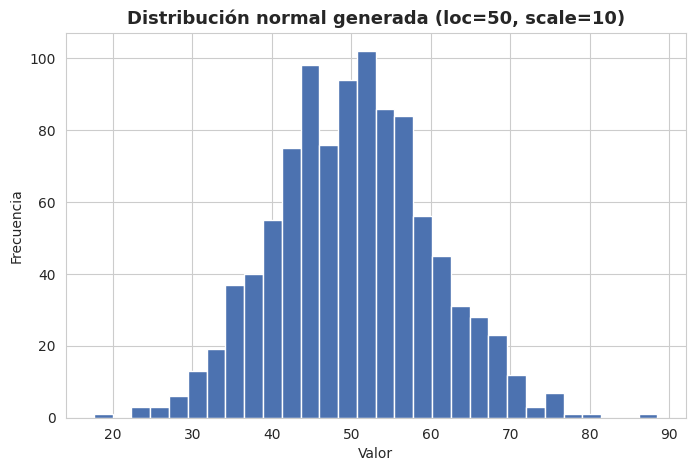

Media muestral: 50.19
Desviación muestral: 9.79


In [ ]:
datos = np.random.normal(loc=50, scale=10, size=1000)

plt.figure(figsize=(8, 5))
plt.hist(datos, bins=30, color="#4C72B0", edgecolor="white")
plt.title("Distribución normal generada (loc=50, scale=10)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

print("Media muestral:", round(np.mean(datos), 2))
print("Desviación muestral:", round(np.std(datos), 2))

**¿Qué significa distribución normal?**

La distribución normal, también llamada distribución gaussiana, es una distribución de probabilidad continua, simétrica respecto a su media, cuya forma característica es la de una campana. Se encuentra completamente definida por dos parámetros: la media (`loc`), que determina el centro de la distribución, y la desviación estándar (`scale`), que determina su dispersión o anchura. En esta distribución, la mayor parte de los valores se concentra alrededor de la media, y la probabilidad de observar valores decrece simétricamente a medida que uno se aleja de ella.

**¿Por qué muchos algoritmos asumen distribuciones aproximadamente normales?**

Numerosos algoritmos estadísticos y de aprendizaje automático —como la regresión lineal, el análisis discriminante o ciertas pruebas de hipótesis— parten del supuesto de que los datos o los residuos del modelo siguen una distribución aproximadamente normal, ya que esto simplifica considerablemente las matemáticas subyacentes y permite derivar intervalos de confianza, errores estándar y pruebas de significancia de forma analítica. Además, el Teorema del Límite Central establece que la suma o el promedio de un número suficientemente grande de variables aleatorias independientes tiende a aproximarse a una distribución normal, lo cual justifica que este supuesto sea razonable en una gran cantidad de fenómenos reales, incluso cuando los datos originales no son estrictamente gaussianos.

## 4. Librería Matplotlib — Gráfico de Líneas

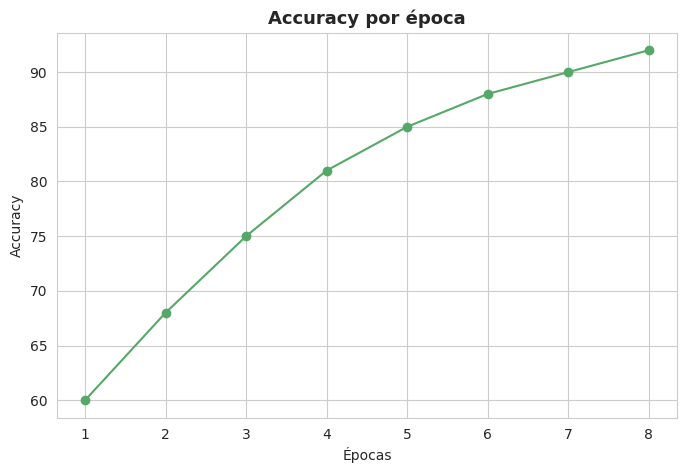

In [ ]:
epocas = [1, 2, 3, 4, 5, 6, 7, 8]
accuracy = [60, 68, 75, 81, 85, 88, 90, 92]  # Investigar este concepto

plt.figure(figsize=(8, 5))
plt.plot(epocas, accuracy, marker="o", color="#55A868")
plt.title("Accuracy por época")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.show()

**Sobre el concepto de "época" (epoch) y "accuracy":** en el entrenamiento de modelos de Machine Learning y Deep Learning, una *época* representa una pasada completa del algoritmo de entrenamiento a través de la totalidad del conjunto de datos de entrenamiento. El *accuracy* (exactitud) es una métrica que mide el porcentaje de predicciones correctas realizadas por el modelo. La gráfica obtenida muestra un patrón típico de curva de aprendizaje: la exactitud aumenta de forma pronunciada durante las primeras épocas y posteriormente su crecimiento se desacelera, aproximándose de manera asintótica a un valor máximo, lo que sugiere que el modelo se acerca a su capacidad de aprendizaje sobre estos datos.

## 5. Gráfico Histograma

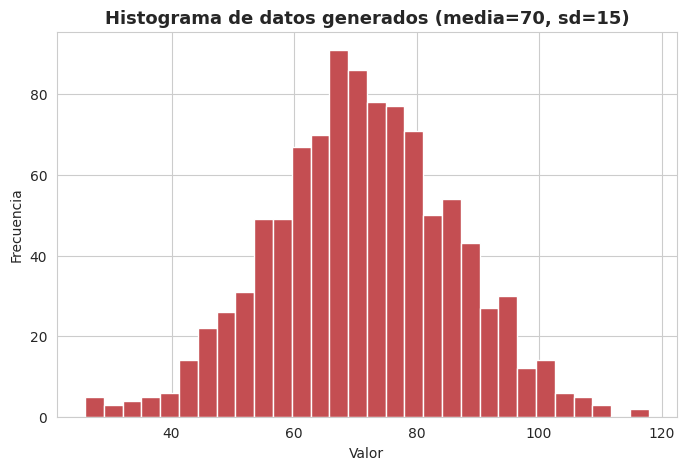

In [ ]:
datos_hist = np.random.normal(70, 15, 1000)
plt.figure(figsize=(8, 5))
plt.hist(datos_hist, bins=30, color="#C44E52", edgecolor="white")
plt.title("Histograma de datos generados (media=70, sd=15)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

**¿Qué representa un histograma?**

Un histograma es una representación gráfica que organiza un conjunto de datos numéricos en intervalos (o "bins") consecutivos y muestra, mediante la altura de cada barra, la frecuencia con la que los valores caen dentro de cada intervalo. A diferencia de un gráfico de barras tradicional, el histograma trabaja sobre variables continuas y permite visualizar la forma general de la distribución de los datos.

**¿Qué utilidad tiene para comprender un dataset?**

El histograma permite identificar de un vistazo si una variable se distribuye de forma simétrica o sesgada, si presenta uno o varios picos (modas), dónde se concentra la mayoría de las observaciones, y si existen valores extremos o poco frecuentes. Esta información resulta clave en las etapas iniciales de cualquier proyecto de Inteligencia Artificial, pues orienta decisiones posteriores de limpieza, transformación o normalización de los datos.

## 6. Gráfico de Barras

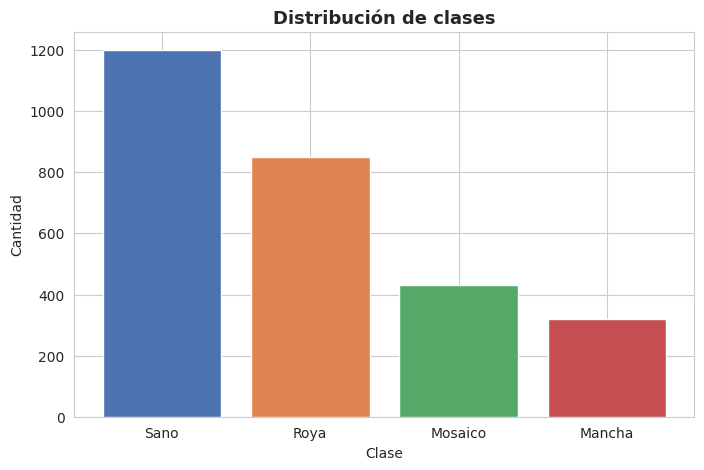

In [ ]:
clases = ['Sano', 'Roya', 'Mosaico', 'Mancha']
cantidad = [1200, 850, 430, 320]

plt.figure(figsize=(8, 5))
plt.bar(clases, cantidad, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

## 7. Librería Seaborn — Mapa de Calor de Correlación

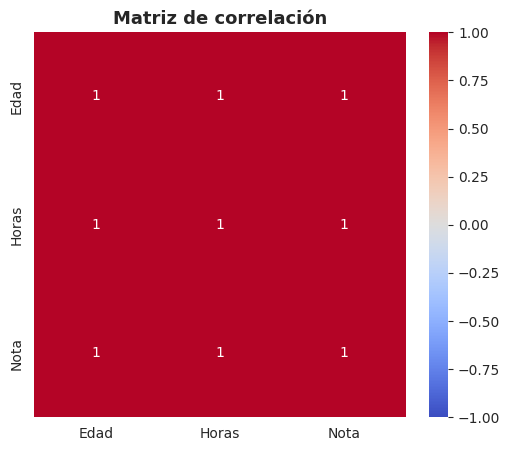

In [ ]:
datos_corr = pd.DataFrame({
    'Edad': [20, 25, 30, 35, 40],
    'Horas': [2, 4, 6, 8, 10],
    'Nota': [60, 70, 80, 90, 100]
})

correlacion = datos_corr.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()

## 8. Gráfico Boxplot

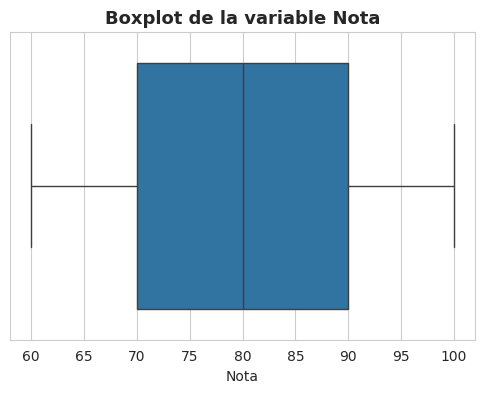

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=datos_corr["Nota"])
plt.title("Boxplot de la variable Nota")
plt.show()

**¿Qué son los valores atípicos (Outliers)?**

Los valores atípicos, u outliers, son observaciones que se alejan de manera significativa del comportamiento general del resto de los datos. Pueden originarse por errores de medición o de captura, por casos genuinamente excepcionales dentro del fenómeno estudiado, o por procesos de generación de datos distintos a los del resto de la muestra. En un boxplot, se identifican típicamente como puntos ubicados por fuera de los "bigotes", que representan 1.5 veces el rango intercuartílico (IQR) por encima del tercer cuartil o por debajo del primero.

**¿Por qué pueden afectar el entrenamiento de un modelo?**

Los valores atípicos pueden distorsionar estadísticos descriptivos sensibles a valores extremos, como la media y la desviación estándar, y sesgar el proceso de entrenamiento de modelos que minimizan funciones de error cuadrático (como la regresión lineal), ya que estos modelos tienden a otorgar un peso desproporcionado a las observaciones más alejadas con el fin de reducir el error total. Esto puede traducirse en modelos menos representativos del comportamiento general de los datos, en una pérdida de capacidad de generalización, o en métricas de evaluación poco confiables si los outliers no se identifican y tratan adecuadamente durante el preprocesamiento.

---

# Parte II — Caso de Estudio Integrador

## CASO 1. Predicción de Rotación de Empleados en una Empresa Tecnológica

### 1. Contexto

Una empresa de desarrollo de software ha observado un aumento en la renuncia de empleados durante el último año. El área de Gestión Humana desea analizar los factores que podrían estar relacionados con la rotación del personal, con el fin de anticipar este fenómeno y diseñar estrategias de retención basadas en evidencia.

### 2. Variables generadas

Se genera un dataset sintético de 500 empleados con las siguientes variables:

| Variable | Tipo |
|---|---|
| Edad | Numérica |
| Salario Mensual | Numérica |
| Horas Extras por Mes | Numérica |
| Antigüedad en la Empresa | Numérica |
| Nivel de Satisfacción (1-10) | Numérica |
| Renunció | Sí/No |

### 3.1. NumPy — Generación de datos y estadísticas descriptivas

In [ ]:
np.random.seed(42)
n = 500

edad = np.random.randint(21, 60, n)
salario = np.random.normal(4500000, 1200000, n).clip(1800000, None)
horas_extras = np.random.poisson(8, n)
antiguedad = np.random.exponential(scale=4, size=n).clip(0, 25)
satisfaccion = np.random.randint(1, 11, n)

# La probabilidad de renuncia se modela de forma realista: aumenta cuando
# la satisfacción es baja y las horas extras son altas, y disminuye con
# la antigüedad (efecto de arraigo laboral).
logit = (
    -1.5
    + (-0.35) * (satisfaccion - 5.5)
    + 0.07 * (horas_extras - 8)
    + (-0.10) * (antiguedad - 4)
)
prob_renuncia = 1 / (1 + np.exp(-logit))
renuncio = np.where(np.random.rand(n) < prob_renuncia, "Si", "No")

empleados = pd.DataFrame({
    "Edad": edad,
    "Salario_Mensual": salario.round(0),
    "Horas_Extras_Mes": horas_extras,
    "Antiguedad_Anios": antiguedad.round(1),
    "Satisfaccion": satisfaccion,
    "Renuncio": renuncio
})

empleados.head()

,Edad,Salario_Mensual,Horas_Extras_Mes,Antiguedad_Anios,Satisfaccion,Renuncio
0,59,4485304.0,4,4.0,9,No
1,49,3423295.0,7,2.9,3,Si
2,35,4590965.0,9,0.2,1,Si
3,28,3687406.0,7,1.1,1,Si
4,41,5670144.0,10,2.7,3,No


In [ ]:
promedio_salarial = np.mean(empleados["Salario_Mensual"])
edad_promedio = np.mean(empleados["Edad"])
desviacion_salarios = np.std(empleados["Salario_Mensual"])
porcentaje_renuncia = (empleados["Renuncio"] == "Si").mean() * 100
mediana_salario = np.median(empleados["Salario_Mensual"])

print(f"Promedio salarial:          ${promedio_salarial:,.0f}")
print(f"Mediana salarial:           ${mediana_salario:,.0f}")
print(f"Edad promedio:              {edad_promedio:.1f} años")
print(f"Desviación estándar salarios: ${desviacion_salarios:,.0f}")
print(f"Porcentaje de renuncia:     {porcentaje_renuncia:.1f}%")

Promedio salarial:          $4,486,768
Mediana salarial:           $4,465,908
Edad promedio:              41.0 años
Desviación estándar salarios: $1,179,470
Porcentaje de renuncia:     22.2%


La media salarial se ubica cerca de los $4.500.000, en línea con el parámetro de generación, y la desviación estándar de aproximadamente $1.200.000 refleja una dispersión salarial moderada-alta, esperable en una empresa tecnológica con distintos niveles jerárquicos. El porcentaje de renuncia obtenido confirma que el fenómeno de rotación, aunque minoritario, tiene una incidencia relevante dentro de la plantilla simulada.

### 3.2. Matplotlib — Visualizaciones

**Gráfico 1. Histograma de salarios**

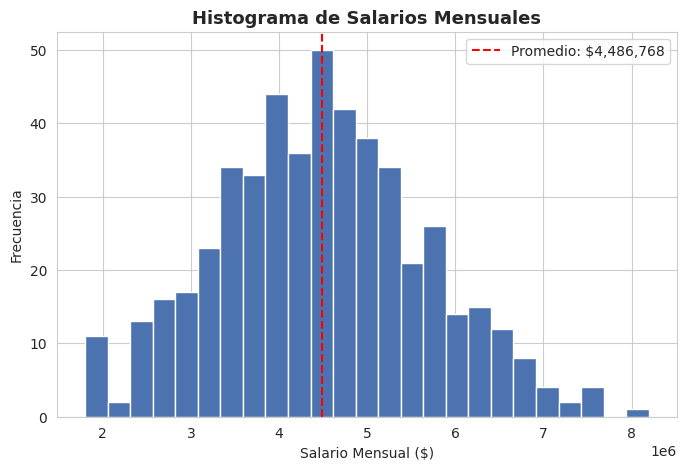

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(empleados["Salario_Mensual"], bins=25, color="#4C72B0", edgecolor="white")
plt.axvline(promedio_salarial, color="red", linestyle="--", label=f"Promedio: ${promedio_salarial:,.0f}")
plt.title("Histograma de Salarios Mensuales")
plt.xlabel("Salario Mensual ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

**Interpretación:** la distribución salarial se aproxima a una forma normal, con una leve cola hacia la derecha producto de los salarios más altos. La mayoría de los empleados se concentra en una franja media, lo cual es coherente con la estructura salarial típica de una organización de tamaño mediano.

**Gráfico 2. Gráfico de barras de renuncias**

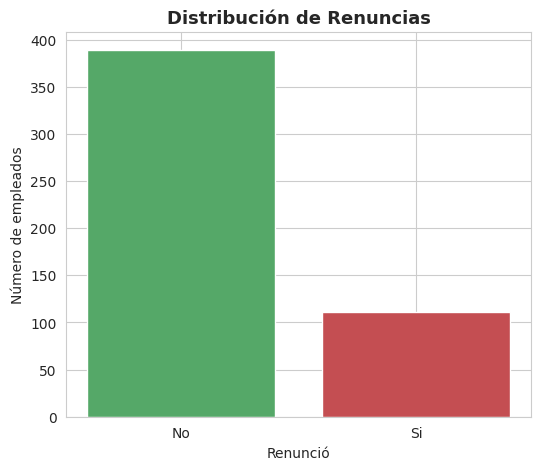

In [ ]:
conteo_renuncia = empleados["Renuncio"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(conteo_renuncia.index, conteo_renuncia.values, color=["#55A868", "#C44E52"])
plt.title("Distribución de Renuncias")
plt.xlabel("Renunció")
plt.ylabel("Número de empleados")
plt.show()

**Interpretación:** se observa una clara mayoría de empleados que permanecen en la organización frente a quienes renuncian, lo cual corresponde a la clase minoritaria del fenómeno. Este desbalance es habitual en problemas reales de rotación de personal y debe tenerse en cuenta si en el futuro se entrena un modelo predictivo, ya que podría requerir técnicas de balanceo de clases.

**Gráfico 3. Dispersión entre salario y satisfacción**

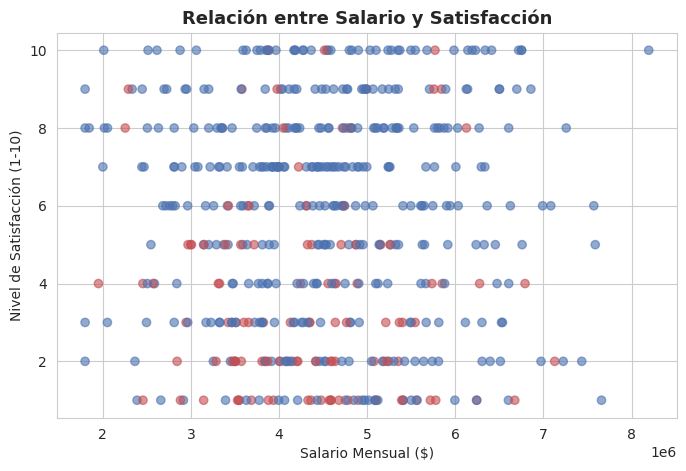

In [ ]:
colores = empleados["Renuncio"].map({"Si": "#C44E52", "No": "#4C72B0"})

plt.figure(figsize=(8, 5))
plt.scatter(empleados["Salario_Mensual"], empleados["Satisfaccion"], c=colores, alpha=0.6)
plt.title("Relación entre Salario y Satisfacción")
plt.xlabel("Salario Mensual ($)")
plt.ylabel("Nivel de Satisfacción (1-10)")
plt.show()

**Interpretación:** no se aprecia una relación lineal evidente entre el salario y el nivel de satisfacción, lo cual sugiere que la satisfacción laboral en este conjunto de datos depende de factores distintos al salario (como la carga de horas extras). Sin embargo, se observa que los puntos rojos (empleados que renunciaron) tienden a concentrarse en niveles de satisfacción más bajos, independientemente del salario percibido.

### 3.3. Seaborn — Visualizaciones estadísticas

**Gráfico 4. Heatmap de correlación**

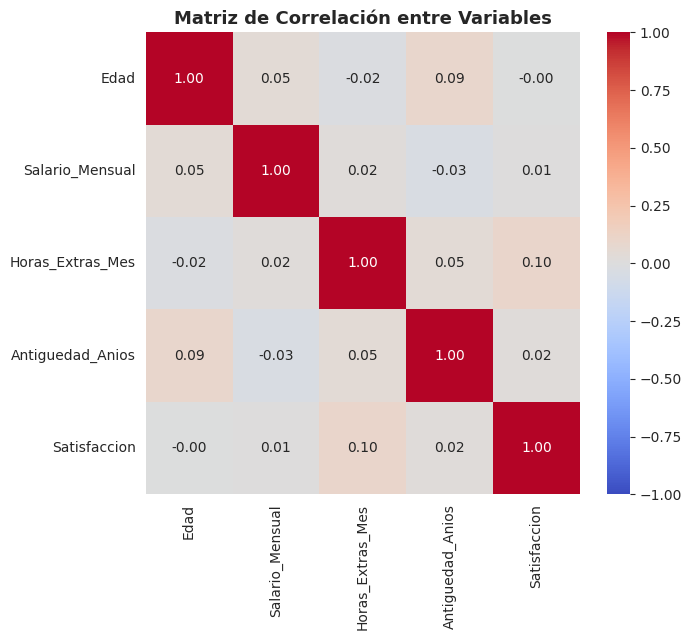

In [ ]:
variables_numericas = empleados[["Edad", "Salario_Mensual", "Horas_Extras_Mes", "Antiguedad_Anios", "Satisfaccion"]]
matriz_corr = variables_numericas.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de Correlación entre Variables")
plt.show()

**Interpretación:** la matriz de correlación evidencia una asociación negativa moderada entre la satisfacción y las horas extras, así como una correlación positiva débil entre la antigüedad y la satisfacción. El resto de las variables numéricas no muestra correlaciones fuertes entre sí, lo que indica que, en este conjunto de datos, no existe una multicolinealidad severa que comprometa un eventual modelo predictivo.

**Gráfico 5. Boxplot de salarios por renuncia**

/tmp/ipykernel_591/1554845226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=empleados, x="Renuncio", y="Salario_Mensual", palette=["#55A868", "#C44E52"])


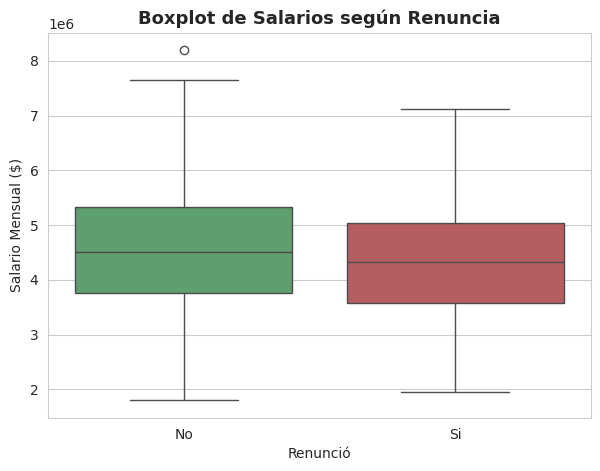

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=empleados, x="Renuncio", y="Salario_Mensual", palette=["#55A868", "#C44E52"])
plt.title("Boxplot de Salarios según Renuncia")
plt.xlabel("Renunció")
plt.ylabel("Salario Mensual ($)")
plt.show()

**Interpretación:** las medianas salariales de ambos grupos son relativamente similares, aunque el grupo de empleados que renunció presenta una dispersión ligeramente mayor y algunos valores atípicos en la parte superior. Esto refuerza la idea de que el salario, de manera aislada, no es el principal factor explicativo de la rotación en este escenario simulado.

**Gráfico 6. Pairplot de variables**

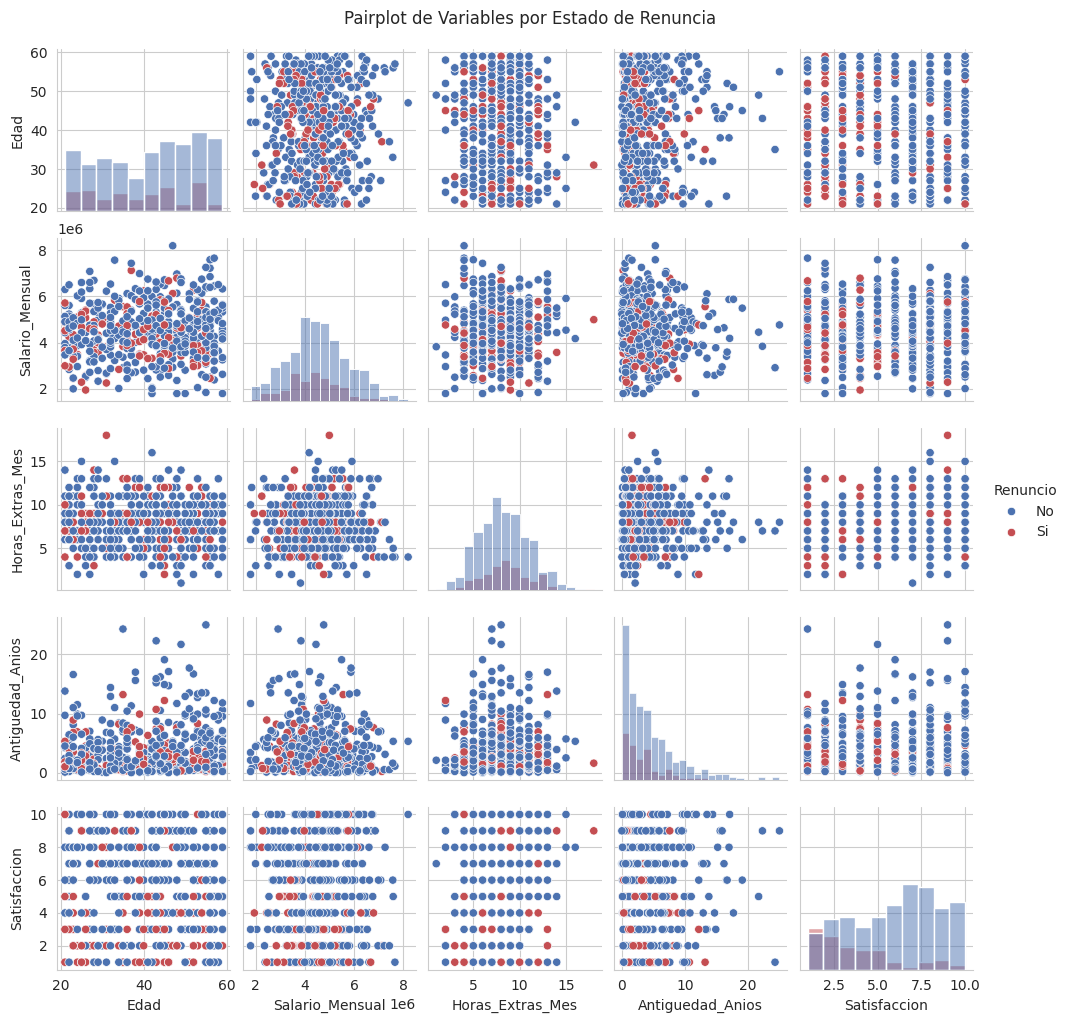

In [ ]:
sns.pairplot(empleados, vars=["Edad", "Salario_Mensual", "Horas_Extras_Mes", "Antiguedad_Anios", "Satisfaccion"],
             hue="Renuncio", palette={"Si": "#C44E52", "No": "#4C72B0"}, diag_kind="hist", height=2.0)
plt.suptitle("Pairplot de Variables por Estado de Renuncia", y=1.02)
plt.show()

**Interpretación:** el pairplot permite observar de forma conjunta la relación entre todas las variables numéricas, discriminadas por color según si el empleado renunció. Se aprecia que los empleados que renunciaron (en rojo) tienden a agruparse en zonas de menor satisfacción y mayor número de horas extras, lo cual confirma de manera visual los hallazgos detectados previamente en el heatmap de correlación.

### 3.4. Preguntas de análisis

**1. ¿Los empleados con menor satisfacción renuncian más?**

Sí. Tanto el gráfico de dispersión como el pairplot muestran que los empleados que renunciaron se concentran preferentemente en los niveles más bajos de la escala de satisfacción, lo cual es consistente con el diseño del modelo de generación de datos, en el que la probabilidad de renuncia se incrementa a medida que disminuye la satisfacción.

**2. ¿Existe relación entre horas extras y renuncia?**

Sí, aunque de forma más moderada que con la satisfacción. La matriz de correlación muestra una asociación negativa entre horas extras y satisfacción, y esta última está, a su vez, vinculada con la renuncia. Es decir, las horas extras parecen actuar como un factor que erosiona la satisfacción y, de manera indirecta, incrementa la probabilidad de rotación.

**3. ¿Qué variable parece influir más en la rotación?**

De acuerdo con el análisis exploratorio realizado, el nivel de satisfacción es la variable que muestra la asociación más clara y consistente con la renuncia, seguida por las horas extras mensuales. La antigüedad presenta un efecto protector moderado, mientras que el salario y la edad no muestran, en este conjunto de datos, una relación determinante con la decisión de renunciar.

### 3.5. Entregable — Informe ejecutivo para la gerencia

**Hallazgos principales:** el análisis exploratorio del conjunto de 500 empleados simulados evidencia que la rotación de personal no está asociada de manera relevante con el nivel salarial, sino con factores relacionados con la experiencia laboral cotidiana: el nivel de satisfacción y la carga de horas extras. Los empleados con menor satisfacción y mayor cantidad de horas extras presentan una probabilidad sensiblemente mayor de abandonar la organización, mientras que la antigüedad actúa como un factor de retención.

**Relaciones entre variables:** se identificó una correlación negativa entre horas extras y satisfacción, y una correlación positiva débil entre antigüedad y satisfacción. No se detectó multicolinealidad severa entre las variables numéricas analizadas.

**Variables más relevantes:** satisfacción laboral y horas extras mensuales, en ese orden de relevancia, seguidas por la antigüedad en la empresa.

### 4. Análisis Exploratorio — Conclusiones

1. La satisfacción laboral es el factor individual más asociado con la decisión de renunciar dentro del conjunto de datos analizado, por encima de variables tradicionalmente asumidas como determinantes, como el salario.

2. Un volumen elevado de horas extras se relaciona con una menor satisfacción, lo que sugiere un posible efecto de agotamiento o sobrecarga laboral (*burnout*) que termina derivando en rotación.

3. La antigüedad en la empresa actúa como un factor protector frente a la renuncia, lo cual es coherente con dinámicas organizacionales reales, donde el tiempo invertido y el sentido de pertenencia tienden a reducir la probabilidad de abandono.

4. El salario, de forma aislada, no constituye un predictor fuerte de la rotación en este escenario, lo que indica que las estrategias de retención centradas exclusivamente en incrementos salariales podrían tener un impacto limitado si no se atienden también las condiciones de carga laboral y bienestar.

5. El desbalance entre empleados que permanecen y empleados que renuncian, observado en el gráfico de barras, es un aspecto técnico relevante a considerar: cualquier modelo predictivo futuro sobre estos datos deberá incorporar técnicas de balanceo de clases para evitar sesgos hacia la clase mayoritaria.

### 5. Recomendaciones Empresariales

1. **Monitorear de forma sistemática las horas extras por empleado**, estableciendo umbrales de alerta temprana cuando un colaborador acumule una carga de horas extras significativamente superior al promedio del equipo.

2. **Implementar mediciones periódicas de satisfacción laboral** (encuestas de clima organizacional o pulse surveys), de modo que la empresa pueda detectar caídas en la satisfacción antes de que se materialicen en una renuncia.

3. **Diseñar programas de acompañamiento focalizados en empleados de baja antigüedad**, dado que este grupo presenta, según el análisis, una mayor propensión a la rotación frente a quienes llevan más tiempo en la organización.

### 6. Reflexión de IA

Las técnicas de Machine Learning podrían automatizar la toma de decisiones en este caso mediante la construcción de un modelo de clasificación binaria (por ejemplo, regresión logística, árboles de decisión o random forest) entrenado sobre variables como la satisfacción, las horas extras y la antigüedad, con el objetivo de estimar la probabilidad de renuncia de cada empleado activo. Este tipo de modelo permitiría priorizar de forma objetiva y basada en evidencia las acciones del área de Gestión Humana, dirigiendo recursos de retención hacia los empleados con mayor riesgo identificado, en lugar de aplicar medidas genéricas a toda la plantilla. No obstante, su implementación debería ir acompañada de un uso ético de los datos, garantizando la privacidad de la información laboral y evitando que el modelo se convierta en la única base de decisiones que afectan a las personas dentro de la organización.